# AI CUP 2026 — 桌球 rally 下一拍預測 (LGBM + TabPFN + GRU + 選手傾向)

預測每個 rally 下一拍 `actionId`(19)、`pointId`(10)、`serverGetPoint`(機率)。評分 `0.4·F1a + 0.4·F1p + 0.2·AUC`。

**最終設計 (誠實 match-CV Overall ≈ 0.341)**:
- 樣本「前綴→下一拍」(保留終結拍)；驗證 sampled 前綴；**GroupKFold by match**(與公開榜校準 0.315↔0.319)。
- 特徵 = base + fold-safe transition `P(next_*|last_a,last_p)` + **fold-safe 選手球種傾向** `P(next_action|next_hitter)`(只給 action/point；server 不用)。
- 模型 = LightGBM ⊕ TabPFN ⊕ 小型 GRU，per-task OOF 權重 + prior-correction。
- 已剔除(無效): 幾何/two-stage/分解、stage-transition、lag45/first/window/role、選手發球得分率、player×state。

In [1]:
import os, time, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score, log_loss, brier_score_loss, average_precision_score, precision_recall_fscore_support)
import lightgbm as lgb, torch, torch.nn as nn
from tabpfn import TabPFNClassifier
from tabpfn_extensions.many_class import ManyClassClassifier
warnings.filterwarnings("ignore")
DATA="../data"; SEED=42; np.random.seed(SEED); torch.manual_seed(SEED); DEV="cuda"
ACLS=np.arange(19); PCLS=np.arange(10)
print("ready | lgbm",lgb.__version__,"torch",torch.__version__,"cuda",torch.cuda.is_available())

/home/ryueee17/.conda/envs/aicup2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ready | lgbm 4.6.0 torch 2.5.1+cu121 cuda True


In [2]:
train=pd.read_csv(f"{DATA}/train.csv"); test=pd.read_csv(f"{DATA}/test_new.csv")
print("train",train.shape,"rallies",train.rally_uid.nunique(),"| test",test.shape,"rallies",test.rally_uid.nunique())

train (84707, 18) rallies 14995 | test (5668, 17) rallies 1845


In [3]:
# ===== 特徵: base + fold-safe transition + 選手球種傾向 =====
STROKE=["strikeId","handId","strengthId","spinId","pointId","actionId","positionId"]; REC=["scoreSelf","scoreOther"]+STROKE
def feats(strokes,sex,L):
    last=strokes[L-1]; f={"sex":sex,"obs_len":L,"obs_parity":L%2,"next_is_server":(L+1)%2,
       "score_self":last["scoreSelf"],"score_other":last["scoreOther"],"score_diff":last["scoreSelf"]-last["scoreOther"],"score_sum":last["scoreSelf"]+last["scoreOther"]}
    for off in range(1,4):
        tag="last" if off==1 else f"lag{off}"
        if L>=off:
            r=strokes[L-off]
            for c in STROKE: f[f"{tag}_{c}"]=r[c]
        else:
            for c in STROKE: f[f"{tag}_{c}"]=-1
    f["mean_spin"]=float(np.mean([strokes[i]["spinId"] for i in range(L)])); f["mean_strength"]=float(np.mean([strokes[i]["strengthId"] for i in range(L)]))
    f["nuniq_point"]=len({strokes[i]["pointId"] for i in range(L)}); f["nuniq_action"]=len({strokes[i]["actionId"] for i in range(L)})
    f["_la"]=last["actionId"]; f["_lp"]=last["pointId"]
    return f
def test_len_dist(t): return t.groupby("rally_uid").size().value_counts().to_dict()
def build(df,mode,tld,seed=SEED,test_mode=False):
    rng=np.random.default_rng(seed)
    if mode=="sampled": Ls=np.array(sorted(tld)); Ps=np.array([tld[l] for l in Ls],float); Ps/=Ps.sum()
    rows,yA,yP,yR,g,nh,uid=[],[],[],[],[],[],[]
    for rid,grp in df.groupby("rally_uid",sort=False):
        grp=grp.sort_values("strikeNumber"); T=len(grp); st=grp[REC].to_dict("records"); go=grp.gamePlayerOtherId.to_numpy()
        if test_mode: Ll=[T]
        else:
            if T<2: continue
            na=grp.actionId.to_numpy(); npt=grp.pointId.to_numpy(); sgp=int(grp.serverGetPoint.iloc[0])
            Ll=range(1,T) if mode=="all" else ([1] if len(Ls[Ls<=T-1])==0 else [int(rng.choice(Ls[Ls<=T-1],p=(Ps[Ls<=T-1]/Ps[Ls<=T-1].sum())))])
        for L in Ll:
            rows.append(feats(st,int(grp.sex.iloc[0]),L)); nh.append(int(go[L-1]))
            if test_mode: uid.append(int(rid))
            else: yA.append(int(na[L])); yP.append(int(npt[L])); yR.append(sgp); g.append(int(grp.match.iloc[0]))
    X=pd.DataFrame(rows)
    if test_mode: return X,np.array(nh),np.array(uid)
    return X,np.array(yA),np.array(yP),np.array(yR),np.array(g),np.array(nh)
def fit_trans(keys,yA,yP,alpha=1.0):
    def cd(ka,y,nc):
        d={}
        for k,yy in zip(ka,y): d.setdefault(k,np.zeros(nc))[yy]+=1
        gp=np.bincount(y,minlength=nc)+alpha; gp/=gp.sum(); return {k:(v+alpha)/(v.sum()+alpha*nc) for k,v in d.items()},gp
    lalp=list(zip(keys["_la"],keys["_lp"])); return dict(aJ=cd(lalp,yA,19),pJ=cd(lalp,yP,10))
def apply_trans(keys,T):
    out={}; lalp=list(zip(keys["_la"],keys["_lp"]))
    d,gp=T["aJ"]; M=np.array([d.get(k,gp) for k in lalp])
    for j in range(19): out[f"tA_{j}"]=M[:,j]
    d,gp=T["pJ"]; M=np.array([d.get(k,gp) for k in lalp])
    for j in range(10): out[f"tP_{j}"]=M[:,j]
    return pd.DataFrame(out)
def player_dists(nh,yA,yP,alpha=10):
    dA={};dP={}
    for h,a in zip(nh,yA): dA.setdefault(h,np.zeros(19))[a]+=1
    for h,p in zip(nh,yP): dP.setdefault(h,np.zeros(10))[p]+=1
    gA=np.bincount(yA,minlength=19)+1.;gA/=gA.sum();gP=np.bincount(yP,minlength=10)+1.;gP/=gP.sum()
    return ({h:(v+alpha*gA)/(v.sum()+alpha) for h,v in dA.items()},gA,{h:(v+alpha*gP)/(v.sum()+alpha) for h,v in dP.items()},gP)
def player_feat(nh,dA,gA,dP,gP,idx):
    MA=np.array([dA.get(h,gA) for h in nh]); MP=np.array([dP.get(h,gP) for h in nh])
    return pd.DataFrame({**{f'phA{j}':MA[:,j] for j in range(19)},**{f'phP{j}':MP[:,j] for j in range(10)}},index=idx)
print("tabular feats ready")

tabular feats ready


In [4]:
# ===== GRU (序列模型) =====
CAT=["actionId","pointId","spinId","strengthId","handId","positionId","strikeId"]
VOCAB={c:int(train[c].max())+2 for c in CAT}; VOCAB["role"]=3; VOCAB["sex"]=int(train.sex.max())+2; NCAT=len(CAT)+2; MAXLEN=30
def rseq(g):
    g=g.sort_values("strikeNumber")
    cat=np.stack([g[c].to_numpy()+1 for c in CAT]+[(g.strikeNumber.to_numpy()%2)+1,np.full(len(g),int(g.sex.iloc[0])+1)],axis=1)
    num=np.stack([g.scoreSelf.to_numpy()/10.,g.scoreOther.to_numpy()/10.,g.strikeNumber.to_numpy()/15.],axis=1)
    sgp=int(g.serverGetPoint.iloc[0]) if "serverGetPoint" in g.columns else 0
    return cat.astype(np.int64),num.astype(np.float32),g.actionId.to_numpy(),g.pointId.to_numpy(),sgp,(int(g.match.iloc[0]) if "match" in g.columns else 0)
def build_seq(df,mode,tld,seed=SEED,test_mode=False):
    rng=np.random.default_rng(seed)
    if mode=="sampled": Ls=np.array(sorted(tld)); Ps=np.array([tld[l] for l in Ls],float); Ps/=Ps.sum()
    C=[];Nu=[];Ln=[];yA=[];yP=[];yR=[];g=[]
    for _,grp in df.groupby("rally_uid",sort=False):
        cat,num,na,npt,sgp,mt=rseq(grp); T=len(na)
        if test_mode: Ll=[T]
        else:
            if T<2: continue
            Ll=range(1,T) if mode=="all" else ([1] if len(Ls[Ls<=T-1])==0 else [int(rng.choice(Ls[Ls<=T-1],p=(Ps[Ls<=T-1]/Ps[Ls<=T-1].sum())))])
        for L in Ll:
            l=min(L,MAXLEN); pc=np.zeros((MAXLEN,NCAT),np.int64); pn=np.zeros((MAXLEN,3),np.float32)
            pc[:l]=cat[L-l:L]; pn[:l]=num[L-l:L]; C.append(pc);Nu.append(pn);Ln.append(l)
            if not test_mode: yA.append(int(na[L]));yP.append(int(npt[L]));yR.append(sgp);g.append(mt)
    if test_mode: return np.stack(C),np.stack(Nu),np.array(Ln)
    return np.stack(C),np.stack(Nu),np.array(Ln),np.array(yA),np.array(yP),np.array(yR),np.array(g)
class GRUNet(nn.Module):
    def __init__(s):
        super().__init__(); s.embs=nn.ModuleList([nn.Embedding(VOCAB[c],8,padding_idx=0) for c in CAT]+[nn.Embedding(VOCAB["role"],4,padding_idx=0),nn.Embedding(VOCAB["sex"],4,padding_idx=0)])
        s.num=nn.Linear(3,16); s.gru=nn.GRU(8*len(CAT)+4+4+16,64,batch_first=True); s.drop=nn.Dropout(0.2); s.ha=nn.Linear(64,19);s.hp=nn.Linear(64,10);s.hs=nn.Linear(64,1)
    def forward(s,cat,num,ln):
        e=torch.cat([s.embs[i](cat[:,:,i]) for i in range(NCAT)]+[torch.relu(s.num(num))],-1)
        pk=nn.utils.rnn.pack_padded_sequence(e,ln.cpu(),batch_first=True,enforce_sorted=False); _,h=s.gru(pk); h=s.drop(h[-1])
        return s.ha(h),s.hp(h),s.hs(h).squeeze(1)
def _cw(y,n): c=np.bincount(y,minlength=n)+1; w=1./c; return torch.tensor(w*n/w.sum(),dtype=torch.float32,device=DEV)
def gru_train(Xc,Xn,Xl,yA,yP,yR,idx,ep=12):
    m=GRUNet().to(DEV); opt=torch.optim.Adam(m.parameters(),1e-3)
    cea=nn.CrossEntropyLoss(weight=_cw(yA[idx],19));cep=nn.CrossEntropyLoss(weight=_cw(yP[idx],10));bce=nn.BCEWithLogitsLoss()
    Cc=torch.tensor(Xc[idx],device=DEV);Nn=torch.tensor(Xn[idx],device=DEV);Ll=torch.tensor(Xl[idx],device=DEV)
    Ta=torch.tensor(yA[idx],device=DEV);Tp=torch.tensor(yP[idx],device=DEV);Trr=torch.tensor(yR[idx].astype("float32"),device=DEV); ii=np.arange(len(idx))
    for e in range(ep):
        m.train();np.random.shuffle(ii)
        for i in range(0,len(ii),256):
            b=ii[i:i+256];opt.zero_grad();la,lp,lr=m(Cc[b],Nn[b],Ll[b]);(0.4*cea(la,Ta[b])+0.4*cep(lp,Tp[b])+0.2*bce(lr,Trr[b])).backward();opt.step()
    return m
def gru_pred(m,Xc,Xn,Xl,idx):
    m.eval();A=[];P=[];R=[]
    with torch.no_grad():
        for i in range(0,len(idx),512):
            j=idx[i:i+512]; la,lp,lr=m(torch.tensor(Xc[j],device=DEV),torch.tensor(Xn[j],device=DEV),torch.tensor(Xl[j],device=DEV))
            A.append(torch.softmax(la,1).cpu().numpy());P.append(torch.softmax(lp,1).cpu().numpy());R.append(torch.sigmoid(lr).cpu().numpy())
    return np.vstack(A),np.vstack(P),np.concatenate(R)
print("GRU ready")

GRU ready


In [5]:
# ===== 評估 pipeline =====
def official_score(a,p,u): return 0.4*a+0.4*p+0.2*u
def clf_diag(name,y,proba,cls,verbose=True):
    cls=np.asarray(cls); pred=cls[proba.argmax(1)]; macro=f1_score(y,pred,average="macro")
    if verbose:
        pr,rc,f1,sp=precision_recall_fscore_support(y,pred,labels=cls,zero_division=0)
        print(f"[{name}] macroF1={macro:.4f} wF1={f1_score(y,pred,average='weighted'):.4f} acc={accuracy_score(y,pred):.4f}")
        print(pd.DataFrame({"prec":pr.round(3),"rec":rc.round(3),"f1":f1.round(3),"sup":sp},index=cls).to_string())
    return macro
def bin_diag(name,y,prob):
    prob=np.clip(prob,1e-7,1-1e-7); auc=roc_auc_score(y,prob)
    print(f"[{name}] AUC={auc:.4f} logloss={log_loss(y,prob,labels=[0,1]):.4f} brier={brier_score_loss(y,prob):.4f} PR-AUC={average_precision_score(y,prob):.4f} prob μ={prob.mean():.3f} σ={prob.std():.3f}")
    return auc
def fold_report(fid,trg,vag):
    ov=set(trg)&set(vag)
    if ov: raise ValueError(f"[fold {fid}] match overlap")
    return dict(fold=fid,train=len(trg),valid=len(vag),tr_m=len(set(trg)),va_m=len(set(vag)),overlap=0)
def log_experiment(row,path="../experiments_log.csv"):
    pd.DataFrame([{**row,"timestamp":pd.Timestamp.now().isoformat(timespec="seconds")}]).to_csv(path,mode="a",header=not os.path.exists(path),index=False)
def validate_submission(sub,uids,cols=("rally_uid","actionId","pointId","serverGetPoint")):
    for c in cols:
        if c not in sub.columns: raise ValueError(f"缺欄位 {c}")
    if len(sub)!=len(set(uids)): raise ValueError("row 數不符")
    if sub.rally_uid.duplicated().any() or (set(uids)-set(sub.rally_uid)): raise ValueError("rally_uid 重複/缺漏")
    if sub[list(cols)].isnull().any().any(): raise ValueError("有 null")
    if not sub.serverGetPoint.between(0,1).all(): raise ValueError("serverGetPoint 超界")
    print(f"submission 驗證通過 ✓ rows={len(sub)} action={dict(sub.actionId.value_counts().head(3))} point={dict(sub.pointId.value_counts().head(3))} sgp μ={sub.serverGetPoint.mean():.3f}")
def prior_of(y,cls): return np.array([(y==c).mean() for c in cls])
def align(p,c,full):
    o=np.zeros((p.shape[0],len(full))); idx={cc:i for i,cc in enumerate(c)}
    for j,cc in enumerate(full):
        if cc in idx: o[:,j]=p[:,idx[cc]]
    return o
def lgbc(bal=True): return lgb.LGBMClassifier(n_estimators=400,learning_rate=0.05,num_leaves=63,subsample=0.8,colsample_bytree=0.8,class_weight=("balanced" if bal else None),random_state=SEED,n_jobs=-1,verbose=-1)
def beta_macro(p,y,cls,pr):
    b0=(-1.,0.)
    for b in np.linspace(0,1.5,16):
        fb=f1_score(y,cls[(p/np.clip(pr,1e-9,None)**b).argmax(1)],average="macro")
        if fb>b0[0]: b0=(fb,b)
    return b0
def s3(L,T,G,y,cls,pr):
    best=(-1,None,0)
    for wl in np.arange(0,1.01,0.1):
        for wt in np.arange(0,1.01-wl+1e-9,0.1):
            wg=round(1-wl-wt,2)
            if wg<-1e-9: continue
            f1,b=beta_macro(wl*L+wt*T+wg*G,y,cls,pr)
            if f1>best[0]: best=(f1,(round(wl,1),round(wt,1),wg),b)
    return best
def s3a(L,T,G,y):
    best=(-1,None)
    for wl in np.arange(0,1.01,0.1):
        for wt in np.arange(0,1.01-wl+1e-9,0.1):
            wg=round(1-wl-wt,2)
            if wg<-1e-9: continue
            a=roc_auc_score(y,wl*L+wt*T+wg*G)
            if a>best[0]: best=(a,(round(wl,1),round(wt,1),wg))
    return best
print("eval pipeline ready")

eval pipeline ready


In [6]:
# ===== 建樣本 + fold(by match) =====
tld=test_len_dist(test)
Xa,yA,yP,yR,ga,nha=build(train,"all",tld); Xs,eA,eP,eR,gs,nhs=build(train,"sampled",tld)
KEY=["_la","_lp"]; BASE=[c for c in Xa.columns if c not in KEY]
matches=np.array(sorted(set(ga)|set(gs))); gkf=GroupKFold(5); fo={}
for f,(_,vi) in enumerate(gkf.split(matches,groups=matches)):
    for m in matches[vi]: fo[m]=f
af=np.array([fo[m] for m in ga]); sf=np.array([fo[m] for m in gs])
prA=prior_of(yA,ACLS); prP=prior_of(yP,PCLS)
print("all",Xa.shape,"sampled",Xs.shape)
for f in range(5): print(fold_report(f,ga[af!=f],gs[sf==f]))

all (69712, 35) sampled (14995, 35)
{'fold': 0, 'train': 57087, 'valid': 2706, 'tr_m': 172, 'va_m': 44, 'overlap': 0}
{'fold': 1, 'train': 57709, 'valid': 2944, 'tr_m': 173, 'va_m': 43, 'overlap': 0}
{'fold': 2, 'train': 54122, 'valid': 3218, 'tr_m': 173, 'va_m': 43, 'overlap': 0}
{'fold': 3, 'train': 56094, 'valid': 2986, 'tr_m': 173, 'va_m': 43, 'overlap': 0}
{'fold': 4, 'train': 53836, 'valid': 3141, 'tr_m': 173, 'va_m': 43, 'overlap': 0}


## §1 OOF 機率 (action/point 含選手傾向; server 不含; 三模型) — 含快取

In [7]:
# action/point: BASE+transition+player ; server: BASE+transition ; GRU: 序列
if os.path.exists("oof_v2.npz"):
    z=np.load("oof_v2.npz"); LAp,LPp,LR,TAp,TPp,TR,YA,YP,YR,evfold=[z[k] for k in ["LAp","LPp","LR","TAp","TPp","TR","YA","YP","YR","evfold"]]
    print("loaded cached oof_v2")
else:
    LAp,LPp,LR,TAp,TPp,TR,YA,YP,YR,evfold=[[] for _ in range(10)]
    for f in range(5):
        trm=af!=f; evm=sf==f; sm=sf!=f; t=time.time()
        T=fit_trans({k:Xa.loc[trm,k].to_numpy() for k in KEY},yA[trm],yP[trm])
        dA,gA,dP,gP=player_dists(nha[trm],yA[trm],yP[trm])
        def AP(Xb,nh,idx):
            Ft=apply_trans({k:Xb[k].to_numpy() for k in KEY},T); Ft.index=idx
            return pd.concat([Xb[BASE],Ft,player_feat(nh,dA,gA,dP,gP,idx)],axis=1)
        def SV(Xb,idx):
            Ft=apply_trans({k:Xb[k].to_numpy() for k in KEY},T); Ft.index=idx
            return pd.concat([Xb[BASE],Ft],axis=1)
        XtAP=AP(Xa.loc[trm],nha[trm],Xa.index[trm]); XeAP=AP(Xs.loc[evm],nhs[evm],Xs.index[evm]); XsAP=AP(Xs.loc[sm],nhs[sm],Xs.index[sm])
        XtS=SV(Xa.loc[trm],Xa.index[trm]); XeS=SV(Xs.loc[evm],Xs.index[evm]); XsS=SV(Xs.loc[sm],Xs.index[sm])
        ma=lgbc().fit(XtAP,yA[trm]); LAp.append(align(ma.predict_proba(XeAP),ma.classes_,ACLS))
        mp=lgbc().fit(XtAP,yP[trm]); LPp.append(align(mp.predict_proba(XeAP),mp.classes_,PCLS))
        mr=lgbc(False).fit(XtS,yR[trm]); LR.append(mr.predict_proba(XeS)[:,1])
        mc=ManyClassClassifier(estimator=TabPFNClassifier(device=DEV,ignore_pretraining_limits=True),alphabet_size=10,random_state=SEED).fit(XsAP,eA[sm]); TAp.append(align(mc.predict_proba(XeAP),mc.classes_,ACLS))
        bp=TabPFNClassifier(device=DEV,ignore_pretraining_limits=True).fit(XsAP,eP[sm]); TPp.append(align(bp.predict_proba(XeAP),bp.classes_,PCLS))
        br=TabPFNClassifier(device=DEV,ignore_pretraining_limits=True).fit(XsS,eR[sm]); TR.append(br.predict_proba(XeS)[:,1])
        YA.append(eA[evm]);YP.append(eP[evm]);YR.append(eR[evm]);evfold.append(np.full(evm.sum(),f)); print(f"  fold{f} {time.time()-t:.0f}s")
    LAp=np.vstack(LAp);LPp=np.vstack(LPp);LR=np.concatenate(LR);TAp=np.vstack(TAp);TPp=np.vstack(TPp);TR=np.concatenate(TR)
    YA=np.concatenate(YA);YP=np.concatenate(YP);YR=np.concatenate(YR);evfold=np.concatenate(evfold)
    np.savez("oof_v2.npz",LAp=LAp,LPp=LPp,LR=LR,TAp=TAp,TPp=TPp,TR=TR,YA=YA,YP=YP,YR=YR,evfold=evfold)
# GRU OOF
if os.path.exists("gru_oof.npz"):
    zg=np.load("gru_oof.npz"); GA,GP,GR=zg["GA"],zg["GP"],zg["GR"]; assert np.array_equal(zg["YA"],YA); print("loaded cached GRU OOF")
else:
    Ca,Na,La_,gyA,gyP,gyR,gga=build_seq(train,"all",tld); Cs,Ns,Ls_,geA,geP,geR,ggs=build_seq(train,"sampled",tld)
    gaf=np.array([fo[m] for m in gga]); gsf=np.array([fo[m] for m in ggs]); GA=[];GP=[];GR=[]
    for f in range(5):
        m=gru_train(Ca,Na,La_,gyA,gyP,gyR,np.where(gaf!=f)[0]); a,p,r=gru_pred(m,Cs,Ns,Ls_,np.where(gsf==f)[0]); GA.append(a);GP.append(p);GR.append(r)
    GA=np.vstack(GA);GP=np.vstack(GP);GR=np.concatenate(GR); np.savez("gru_oof.npz",GA=GA,GP=GP,GR=GR,YA=YA,YP=YP,YR=YR)
print("OOF ready")

loaded cached oof_v2
loaded cached GRU OOF
OOF ready


In [8]:
# 3-way per-task 權重 + β 搜尋 + 診斷
fa,WA,BA=s3(LAp,TAp,GA,YA,ACLS,prA); fp,WP,BP=s3(LPp,TPp,GP,YP,PCLS,prP); au,WR=s3a(LR,TR,GR,YR)
OV=official_score(fa,fp,au)
print(f"action F1a={fa:.4f} w(L,T,G)={WA} b={BA:.2f} | point F1p={fp:.4f} w={WP} b={BP:.2f} | server AUC={au:.4f} w={WR}")
print(f"=> OOF Overall={OV:.4f}")
ensA=WA[0]*LAp+WA[1]*TAp+WA[2]*GA; ensP=WP[0]*LPp+WP[1]*TPp+WP[2]*GP; ensR=WR[0]*LR+WR[1]*TR+WR[2]*GR
fov=[official_score(f1_score(YA[evfold==f],ACLS[(ensA[evfold==f]/np.clip(prA,1e-9,None)**BA).argmax(1)],average="macro"),
                    f1_score(YP[evfold==f],PCLS[(ensP[evfold==f]/np.clip(prP,1e-9,None)**BP).argmax(1)],average="macro"),
                    roc_auc_score(YR[evfold==f],ensR[evfold==f])) for f in range(5)]
print(f"fold mean={np.mean(fov):.4f} std={np.std(fov):.4f}")
adjA=ensA/np.clip(prA,1e-9,None)**BA; adjP=ensP/np.clip(prP,1e-9,None)**BP
clf_diag("action OOF",YA,adjA,ACLS); print(); clf_diag("point OOF",YP,adjP,PCLS); print(); bin_diag("server OOF",YR,ensR)
log_experiment(dict(candidate="LGBM+TabPFN+GRU+player",action_f1=round(fa,4),point_f1=round(fp,4),server_auc=round(au,4),overall=round(OV,4),wA=str(WA),wP=str(WP),wR=str(WR)))

action F1a=0.3539 w(L,T,G)=(np.float64(0.3), np.float64(0.2), np.float64(0.5)) b=0.00 | point F1p=0.1894 w=(np.float64(0.4), np.float64(0.3), np.float64(0.3)) b=0.10 | server AUC=0.6145 w=(np.float64(0.2), np.float64(0.8), np.float64(0.0))
=> OOF Overall=0.3402
fold mean=0.3444 std=0.0066
[action OOF] macroF1=0.3539 wF1=0.4787 acc=0.4790
     prec    rec     f1   sup
0   0.230  0.173  0.197   336
1   0.665  0.630  0.647  3603
2   0.436  0.427  0.431   892
3   0.274  0.223  0.246   264
4   0.385  0.522  0.443  1202
5   0.284  0.202  0.236   615
6   0.401  0.418  0.410  1272
7   0.265  0.308  0.285   610
8   0.153  0.108  0.126   102
9   0.379  0.322  0.348   208
10  0.503  0.474  0.488  2957
11  0.396  0.440  0.417  1123
12  0.662  0.607  0.633   603
13  0.469  0.509  0.488  1167
14  0.286  0.250  0.267    40
15  0.000  0.000  0.000     0
16  0.000  0.000  0.000     1
17  0.000  0.000  0.000     0
18  0.000  0.000  0.000     0

[point OOF] macroF1=0.1894 wF1=0.2684 acc=0.2669
    prec  

## §2 診斷圖: 逐類別 F1

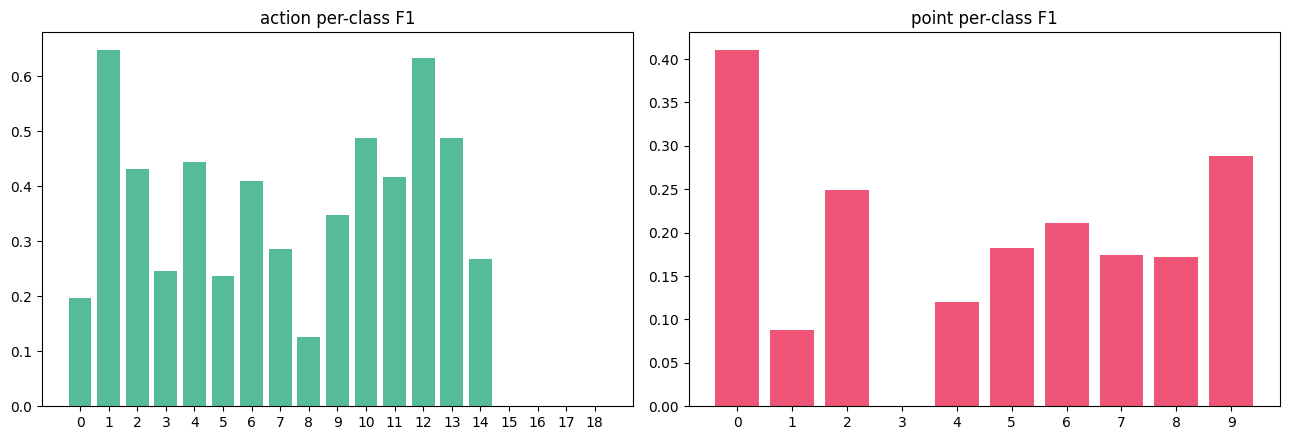

In [9]:
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
af_=precision_recall_fscore_support(YA,ACLS[adjA.argmax(1)],labels=ACLS,zero_division=0)[2]
pf_=precision_recall_fscore_support(YP,PCLS[adjP.argmax(1)],labels=PCLS,zero_division=0)[2]
ax[0].bar(ACLS,af_,color="#5b9");ax[0].set_title("action per-class F1");ax[0].set_xticks(ACLS)
ax[1].bar(PCLS,pf_,color="#e57");ax[1].set_title("point per-class F1");ax[1].set_xticks(PCLS)
plt.tight_layout(); plt.show()

## §3 產生並驗證 submission (全 train 重訓; action/point 含選手傾向)

In [10]:
Xte,nht,uids=build(test,"sampled",tld,test_mode=True); t=time.time()
T=fit_trans({k:Xa[k].to_numpy() for k in KEY},yA,yP); dA,gA,dP,gP=player_dists(nha,yA,yP)
def AP(Xb,nh,idx):
    Ft=apply_trans({k:Xb[k].to_numpy() for k in KEY},T); Ft.index=idx
    return pd.concat([Xb[BASE],Ft,player_feat(nh,dA,gA,dP,gP,idx)],axis=1)
def SV(Xb,idx):
    Ft=apply_trans({k:Xb[k].to_numpy() for k in KEY},T); Ft.index=idx
    return pd.concat([Xb[BASE],Ft],axis=1)
XaAP=AP(Xa,nha,Xa.index); XsAP=AP(Xs,nhs,Xs.index); XteAP=AP(Xte,nht,Xte.index)
XaS=SV(Xa,Xa.index); XsS=SV(Xs,Xs.index); XteS=SV(Xte,Xte.index)
mA=lgbc().fit(XaAP,yA); mP=lgbc().fit(XaAP,yP); mR=lgbc(False).fit(XaS,yR)
tA=ManyClassClassifier(estimator=TabPFNClassifier(device=DEV,ignore_pretraining_limits=True),alphabet_size=10,random_state=SEED).fit(XsAP,eA)
tP=TabPFNClassifier(device=DEV,ignore_pretraining_limits=True).fit(XsAP,eP)
tR=TabPFNClassifier(device=DEV,ignore_pretraining_limits=True).fit(XsS,eR)
Ca,Na,La_,gyA,gyP,gyR,_=build_seq(train,"all",tld); Cte,Nte,Lte=build_seq(test,"sampled",tld,test_mode=True)
gm=gru_train(Ca,Na,La_,gyA,gyP,gyR,np.arange(len(gyA))); gA_,gP_,gR_=gru_pred(gm,Cte,Nte,Lte,np.arange(len(uids)))
PA=WA[0]*align(mA.predict_proba(XteAP),mA.classes_,ACLS)+WA[1]*align(tA.predict_proba(XteAP),tA.classes_,ACLS)+WA[2]*gA_
PP=WP[0]*align(mP.predict_proba(XteAP),mP.classes_,PCLS)+WP[1]*align(tP.predict_proba(XteAP),tP.classes_,PCLS)+WP[2]*gP_
PR=WR[0]*mR.predict_proba(XteS)[:,1]+WR[1]*tR.predict_proba(XteS)[:,1]+WR[2]*gR_
def decide(p,cls,pr,b,mask0):
    adj=p/np.clip(pr,1e-9,None)**b
    if mask0: adj=adj.copy(); adj[:,0]=-1e18
    return cls[adj.argmax(1)]
for tag,mask in [("incl0",False),("excl0",True)]:
    sub=pd.DataFrame({"rally_uid":uids,"actionId":decide(PA,ACLS,prA,BA,mask).astype(int),"pointId":decide(PP,PCLS,prP,BP,mask).astype(int),"serverGetPoint":PR}).sort_values("rally_uid")
    validate_submission(sub,uids); sub.to_csv(f"../submission_player_{tag}.csv",index=False)
print(f"done {time.time()-t:.0f}s")

submission 驗證通過 ✓ rows=1845 action={1: np.int64(412), 13: np.int64(251), 6: np.int64(232)} point={0: np.int64(644), 9: np.int64(425), 8: np.int64(191)} sgp μ=0.535
submission 驗證通過 ✓ rows=1845 action={1: np.int64(414), 13: np.int64(282), 6: np.int64(232)} point={9: np.int64(577), 8: np.int64(526), 7: np.int64(286)} sgp μ=0.535
done 105s
